# Load the Dataset

Here we are working with the `rag-mini-bioasq` database available on hugging face.

In [25]:
from datasets import load_dataset

qap = load_dataset("enelpol/rag-mini-bioasq", "question-answer-passages")
corpus = load_dataset("enelpol/rag-mini-bioasq", "text-corpus")

print(qap)
print(corpus)


DatasetDict({
    train: Dataset({
        features: ['question', 'answer', 'id', 'relevant_passage_ids'],
        num_rows: 4012
    })
    test: Dataset({
        features: ['question', 'answer', 'id', 'relevant_passage_ids'],
        num_rows: 707
    })
})
DatasetDict({
    test: Dataset({
        features: ['passage', 'id'],
        num_rows: 40181
    })
})


Normalize Passages, This ensures consistency for embedding and retrieval.

In [26]:
import re

def normalize_text(text):
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

corpus = corpus.map(lambda x: {"passage": normalize_text(x["passage"])})


Plotting the words and tokens in each "passage"

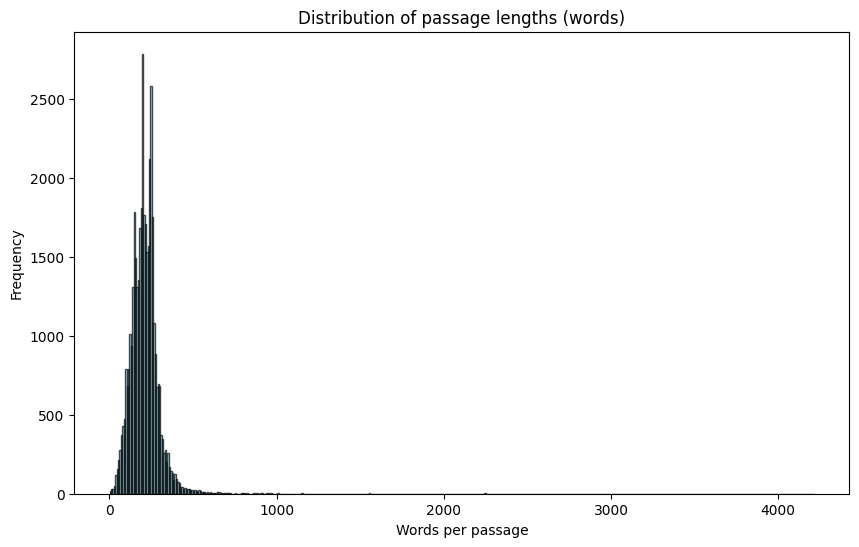

Token indices sequence length is longer than the specified maximum sequence length for this model (661 > 512). Running this sequence through the model will result in indexing errors


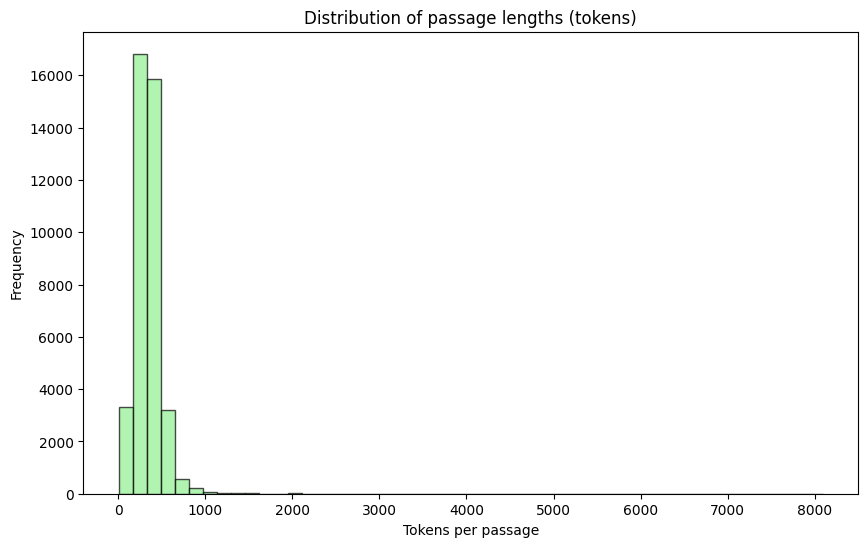

In [27]:
import matplotlib.pyplot as plt

# count words in each passage
word_counts = [len(p.split()) for p in corpus["test"]["passage"]]

plt.figure(figsize=(10,6))
plt.hist(word_counts, bins=500, alpha=0.7, color="skyblue", edgecolor="black")
plt.xlabel("Words per passage")
plt.ylabel("Frequency")
plt.title("Distribution of passage lengths (words)")
plt.show()


# count tokens in each passage using a tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")
token_counts = [len(tokenizer.encode(p, add_special_tokens=False)) for p in corpus["test"]["passage"]]

plt.figure(figsize=(10,6))
plt.hist(token_counts, bins=50, alpha=0.7, color="lightgreen", edgecolor="black")
plt.xlabel("Tokens per passage")
plt.ylabel("Frequency")
plt.title("Distribution of passage lengths (tokens)")
plt.show()


## Chunking
Split Long Passages (Chunking) using sliding windows to maintain continuity in each passage

In [28]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

def chunk_passage(examples, max_tokens=256, overlap=50):
    all_chunks = {"id": [], "passage": []}
    
    for idx, passage in enumerate(examples["passage"]):
        tokens = tokenizer.encode(passage, add_special_tokens=False)
        for i in range(0, len(tokens), max_tokens - overlap):
            chunk_tokens = tokens[i:i+max_tokens]
            chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
            all_chunks["id"].append(f"{examples['id'][idx]}_{i}")
            all_chunks["passage"].append(chunk_text)
            
    return all_chunks

# Apply mapping
corpus_chunks = corpus["test"].map(
    chunk_passage, 
    batched=True, 
    remove_columns=corpus["test"].column_names
)


In [29]:
id2passage = {row["id"]: row["passage"] for row in corpus_chunks}

In [30]:
print(f"Original number of passages: {len(corpus['test'])}")
print(f"Number of passages after chunking: {len(corpus_chunks)}")

Original number of passages: 40181
Number of passages after chunking: 86023


# Naive RAG Approach

## Baseline embeddings

In [31]:
from sentence_transformers import SentenceTransformer
import numpy as np
import faiss

# Load model
embed_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# Encode all chunks
chunk_texts = [row["passage"] for row in corpus_chunks]
chunk_ids = [row["id"] for row in corpus_chunks]

print(f"Number of chunks to embed: {len(chunk_texts)}")
embeddings = embed_model.encode(chunk_texts, show_progress_bar=True, convert_to_numpy=True)


Number of chunks to embed: 86023


Batches: 100%|██████████| 2689/2689 [09:20<00:00,  4.80it/s]


## Building FAISS index

In [32]:
d = embeddings.shape[1]  # embedding dimension
index = faiss.IndexFlatL2(d)  # L2 distance
index.add(embeddings)

print(f"FAISS index built. Total vectors indexed: {index.ntotal}")

FAISS index built. Total vectors indexed: 86023


## Naive retrieval function

In [33]:
def retrieve_top_k(query, k=10):
    query_emb = embed_model.encode([query], convert_to_numpy=True)
    D, I = index.search(query_emb, k)
    results = [{"id": chunk_ids[i], "passage": chunk_texts[i], "distance": float(D[0][idx])} for idx, i in enumerate(I[0])]
    return results


## Quick Stats
Overview of your chunks, passages, and questions. 

Distribution of relevant passages per question

In [39]:
# Total original passages
print(f"Original passages: {len(corpus['test'])}")

# Total chunks
print(f"Chunks after tokenization: {len(corpus_chunks)}")

# Average chunk length in words
avg_words = np.mean([len(p.split()) for p in chunk_texts])
print(f"Average chunk length (words): {avg_words:.2f}")

# Max / Min chunk length
max_words = max(len(p.split()) for p in chunk_texts)
min_words = min(len(p.split()) for p in chunk_texts)
print(f"Max chunk words: {max_words}, Min chunk words: {min_words}")

print('-'*20)

# Number of relevant passages per question
rel_counts = [len(x) for x in qap['test']['relevant_passage_ids']]
print(f"Average relevant passages per question: {np.mean(rel_counts):.2f}")
print(f"Max relevant passages per question: {max(rel_counts)}")
print(f"Min relevant passages per question: {min(rel_counts)}")



Original passages: 40181
Chunks after tokenization: 86023
Average chunk length (words): 130.66
Max chunk words: 241, Min chunk words: 1
--------------------
Average relevant passages per question: 8.66
Max relevant passages per question: 77
Min relevant passages per question: 1


## Explore Retrieval Results

In [45]:
sample_q = qap['test']['question'][0]
print("Sample query:", sample_q)

results = retrieve_top_k(sample_q, k=5)
for idx, res in enumerate(results):
    print(f"\nRank {idx+1}:")
    print("Chunk ID:", res['id'])
    print("Distance:", res['distance'])
    print("Passage snippet:", res['passage'][:], "...")


Sample query: Is capmatinib effective for glioblastoma?

Rank 1:
Chunk ID: 23659608_206
Distance: 0.6684386730194092
Passage snippet: therapy is associated with minimal toxicity, better quality of life, and comparable efficacy to chemotherapy. ongoing and future trials will evaluate ttfields in newly diagnosed glioblastoma, solid tumor brain metastases, nonsmall cell lung cancer, and ovarian and pancreatic cancers. ...

Rank 2:
Chunk ID: 22413865_206
Distance: 0.6777300834655762
Passage snippet: enzastaurin and cediranib failed in randomized phase iii trials in recurrent glioblastoma, aflibercept in phase ii. by contrast, bevacizumab was conditionally approved in many countries. recently completed phase iii trials for bevacizumab and cilengitide in the first - line setting will define the future role of these agents. this intense clinical trial activity reflects the hope that antiangiogenic agents will become part of the limited therapeutic options for glioblastoma. ...

Rank 3:
Chunk 

## RAG Answer Generation via Ollama

In [83]:
from ollama import chat

llm_model = "gemma3:1b"

def generate_rag_answer(query, top_k=5):
    """
    Retrieve top-k passages and generate answer using Ollama LLM.
    Returns: answer string, list of retrieved passage IDs
    """
    retrieved = retrieve_top_k(query, k=top_k)
    retrieved_text = "\n\n".join([r["passage"] for r in retrieved])
    
    prompt = f"""Answer the following question using the context passages.

Context:
{retrieved_text}

Question: {query}
Answer:"""
    
    response = chat(model=llm_model, messages=[{"role": "user", "content": prompt}])
    # Corrected access to the LLM output
    # print(response)
    # print(response.message)
    # print(response.message.content)
    
    answer = response.message.content if hasattr(response, "message") else ""
    
    retrieved_ids = [r["id"] for r in retrieved]
    return answer, retrieved_ids

## Evaluation: Recall@k and MRR

In [93]:
def evaluate_rag(test_dataset, top_k=5):
    """
    Evaluate retrieval using Recall@k and MRR.
    test_dataset: list of dicts, each dict has 'question' and 'relevant_passage_ids'
    """
    n = len(test_dataset)
    recall_sum = 0
    mrr_sum = 0
    i = 0
    for example in test_dataset:
        i+=1
        print("Question #", i, "out of", n)
        print("Question:", example["question"])
        _, retrieved_ids = generate_rag_answer(example["question"], top_k=top_k)
        
        relevant_ids = example.get("relevant_passage_ids", [])
        # Map relevant passage IDs to their chunked IDs
        relevant_chunk_ids = []
        for rid in relevant_ids:
            rid_str = str(rid)  # convert integer ID to string
            relevant_chunk_ids.extend([cid for cid in chunk_ids if cid.startswith(rid_str)])
        
        # Compute Recall@k
        hit = any(rid in retrieved_ids for rid in relevant_chunk_ids)
        recall_sum += int(hit)
        
        # Compute MRR
        rank = next((i+1 for i, rid in enumerate(retrieved_ids) if rid in relevant_chunk_ids), 0)
        mrr_sum += 1/rank if rank > 0 else 0
    
    recall = recall_sum / n
    mrr = mrr_sum / n
    return recall, mrr


In [95]:

test_examples = [
    {
        "question": qap['test'][i]['question'],
        "relevant_passage_ids": qap['test'][i]['relevant_passage_ids']
    }
    # for i in range(len(qap['test'])) # uncomment to run on full test set
    for i in range(20)
]

recall, mrr = evaluate_rag(test_examples, top_k=5)
print("="*30)
print(f"Naive RAG baseline (LLM): Recall@5 = {recall:.3f}, MRR = {mrr:.3f}")


Question # 1 out of 20
Question: Is capmatinib effective for glioblastoma?
Question # 2 out of 20
Question: Describe the mechanism of action of ibalizumab.
Question # 3 out of 20
Question: What is the function of Neu5Gc (N-Glycolylneuraminic acid)?
Question # 4 out of 20
Question: What is the mechanism of action of Inclisiran?
Question # 5 out of 20
Question: What is F105-P?
Question # 6 out of 20
Question: Is tubulin acetylation involved in cell motility?
Question # 7 out of 20
Question: Which methods infer 3D genome structure without proximity ligation?
Question # 8 out of 20
Question: Has protein citrullination been implicated in rheumatoid arthritis?
Question # 9 out of 20
Question: Does MC1R palmitoylation reduce pigmentation?
Question # 10 out of 20
Question: What is the function of transthyretin in cerebrospinal fluid?
Question # 11 out of 20
Question: Which cancers can be treated with Selpercatinib?
Question # 12 out of 20
Question: What is the purpose of the Sunnybrook Facial 